# LightGBM Classification

#### 1. Import Required Libraries

In [1]:
import glob
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb

import joblib


#### 2. Load the Precomputed Dataset

In [2]:
files = glob.glob("aug_data_window_global.csv")
dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

In [4]:
df.columns

Index(['match_id', 'match_title', 'team_code', 'home_team_code',
       'away_team_code', 'player_name', 'game_section', 'x_norm_mean',
       'y_norm_mean', 'x_norm_std', 'y_norm_std', 'speed_mean', 'window',
       'dominant_possession', 'window_start_sec', 'window_end_sec',
       'window_duration_sec', 'dominant_possession_team', 'formation',
       'window_global'],
      dtype='object')

In [4]:
df.value_counts("formation")//10 #10 players per window

formation
5-3-2        286
4-2-3-1      273
4-4-2        250
3-1-4-2      224
4-3-3        210
3-4-2-1      190
5-2-3        180
remove       119
3-1-5-1       98
4-2-2-2       86
4-D-2         84
3-4-1-2       82
5-4-1         78
5-2-1-2       64
4-1-4-1       46
3-4-3         40
4-1-3-2       30
5-3-1-1       20
5-1-3-1       10
4-5-1          4
3-5-2          2
4-1-2-1-2      2
Name: count, dtype: int64

In [5]:
# Remove underrepresented classes
min_samples = 30 * 10  # Minimum 30 windows (10 players per window)
counts = df["formation"].value_counts()
valid_classes = counts[counts >= min_samples].index
df = df[df["formation"].isin(valid_classes)].reset_index(drop=True)

# Drop formations marked as 'remove'
df = df[df["formation"] != "remove"].reset_index(drop=True)

#### 3. Feature Re-computation per Tactical Window

In [6]:
def compute_team_features(group):
    x = group["x_norm_mean"].values
    y = group["y_norm_mean"].values

    centroid_x = np.mean(x)
    centroid_y = np.mean(y)
    width = x.max() - x.min()
    length = y.max() - y.min()
    distances = np.sqrt((x - centroid_x) ** 2 + (y - centroid_y) ** 2)
    dist_mean = np.mean(distances)
    dist_std = np.std(distances)

    return pd.Series({
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "width": width,
        "length": length,
        "dist_mean": dist_mean,
        "dist_std": dist_std
    })


# Compute geometric features per window and merge back
team_features = df.groupby("window_global").apply(compute_team_features).reset_index()
df = df.merge(team_features, on="window_global", how="left")

/tmp/ipykernel_1637279/2886997003.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_features = df.groupby("window_global").apply(compute_team_features).reset_index()


#### 4. Define Features and Target

In [7]:
target_col = "formation"
y = df[target_col].astype("category")

# Numeric features (spatial + motion)
num_cols = [
    "x_norm_mean", "y_norm_mean", "x_norm_std", "y_norm_std", "speed_mean",
    "centroid_x", "centroid_y", "width", "length", "dist_mean", "dist_std"
]

# Categorical features (contextual)
cat_cols = ["game_section", "dominant_possession_team"]

#### 5. Split Data (Avoid Leakage Between Windows)

In [8]:
groups = df["window_global"].values
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, y, groups=groups))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

Train samples: 17760, Test samples: 4450


#### 6. Define Preprocessing and LightGBM Model

In [9]:
# Numeric: impute missing values
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
])

# Categorical: impute + OneHotEncode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numeric & categorical preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


In [10]:
# LightGBM classifier
lgbm_clf = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Full pipeline
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", lgbm_clf)
])

#### 7. Train Model

In [11]:
pipe.fit(train_df[num_cols + cat_cols], train_df[target_col])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2813
[LightGBM] [Info] Number of data points in the train set: 17760, number of used features: 15
[LightGBM] [Info] Start training from score -2.317333
[LightGBM] [Info] Start training from score -3.125410
[LightGBM] [Info] Start training from score -3.248012
[LightGBM] [Info] Start training from score -2.471484
[LightGBM] [Info] Start training from score -4.080922
[LightGBM] [Info] Start training from score -4.346625
[LightGBM] [Info] Start training from score -3.955758
[LightGBM] [Info] Start training from score -3.262611
[LightGBM] [Info] Start training from score -2.130261
[LightGBM] [Info] Start training from score -2.311635
[LightGBM] [Info] Start training from score -2.120827
[LightGBM] [Info] Start training from score -3.219439
[LightGBM] [Info] Start training from score -3.493135
[LightGBM

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 8. Evaluate Model

In [12]:
y_test = test_df[target_col]
y_pred = pipe.predict(test_df[num_cols + cat_cols])

print("\n=== LightGBM Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

/home/falih/Mastercode/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM Evaluation ===
Accuracy: 0.7928089887640449

Classification Report:
               precision    recall  f1-score   support

     3-1-4-2       0.80      0.83      0.82       490
     3-1-5-1       0.83      1.00      0.91       200
     3-4-1-2       0.73      0.69      0.71       130
     3-4-2-1       0.87      0.85      0.86       400
       3-4-3       0.89      0.71      0.79       100
     4-1-3-2       1.00      0.71      0.83        70
     4-1-4-1       1.00      0.98      0.99       120
     4-2-2-2       1.00      0.78      0.88       180
     4-2-3-1       0.55      0.32      0.40       620
       4-3-3       0.70      1.00      0.82       340
       4-4-2       0.73      0.88      0.80       370
       4-D-2       0.79      0.85      0.81       130
     5-2-1-2       0.73      0.80      0.77       100
       5-2-3       0.94      0.85      0.89       390
       5-3-2       0.79      0.97      0.87       630
       5-4-1       0.88      0.67      0.76       18

#### 9. Feature Importance Extraction

In [13]:
try:
    # Extract OHE feature names
    ohe = pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
    cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
    all_feature_names = num_cols + cat_feature_names

    importances = pipe.named_steps["model"].feature_importances_

    if len(importances) == len(all_feature_names):
        feat_imp = pd.DataFrame({
            "feature": all_feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False)

        print("\nTop 20 Feature Importances:")
        print(feat_imp.head(20).to_string(index=False))
    else:
        print("\n[Note] Feature count mismatch after OHE — skipping feature importance output.")
except Exception as e:
    print("\n[Warning] Could not extract feature importances:", e)



Top 20 Feature Importances:
                                   feature  importance
                                    length       34486
                                 dist_mean       34240
                                centroid_x       33685
                                     width       33486
                                  dist_std       32495
                                centroid_y       18871
                    game_section_firstHalf        2704
    dominant_possession_team_In_possession        2400
                                speed_mean        1909
                   game_section_secondHalf        1386
dominant_possession_team_Out_of_possession        1213
                                x_norm_std        1202
                                y_norm_std        1155
                               x_norm_mean         623
                               y_norm_mean         338


Label mapping (int -> class):
0 -> 3-1-4-2
1 -> 3-1-5-1
2 -> 3-4-1-2
3 -> 3-4-2-1
4 -> 3-4-3
5 -> 4-1-3-2
6 -> 4-1-4-1
7 -> 4-2-2-2
8 -> 4-2-3-1
9 -> 4-3-3
10 -> 4-4-2
11 -> 4-D-2
12 -> 5-2-1-2
13 -> 5-2-3
14 -> 5-3-2
15 -> 5-4-1
Training until validation scores don't improve for 50 rounds
[100]	train's multi_logloss: 0.0434764	train's multi_error: 0	valid's multi_logloss: 0.845185	valid's multi_error: 0.225393
Early stopping, best iteration is:
[112]	train's multi_logloss: 0.0302069	train's multi_error: 0	valid's multi_logloss: 0.843457	valid's multi_error: 0.213258

Logged metrics: dict_keys(['train', 'valid'])


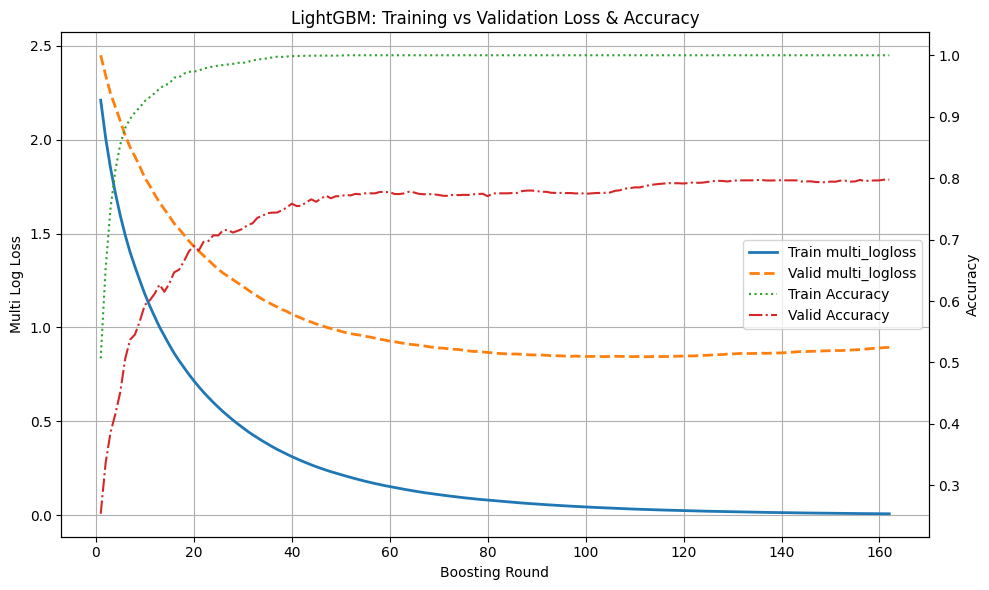


Best iteration: 112

Best scores:
train - multi_logloss: 0.03021
train - multi_error: 0.00000
valid - multi_logloss: 0.84346
valid - multi_error: 0.21326


In [14]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from lightgbm import early_stopping, log_evaluation

# 1) Preprocessing separat fitten (kein Leakage)
preprocess.fit(train_df[num_cols + cat_cols])

X_train = preprocess.transform(train_df[num_cols + cat_cols])
X_test  = preprocess.transform(test_df[num_cols + cat_cols])

# 2) Zielvariable in Integer encodieren
le = LabelEncoder()
y_train_enc = le.fit_transform(train_df[target_col])
y_test_enc  = le.transform(test_df[target_col])

print("Label mapping (int -> class):")
for i, cl in enumerate(le.classes_):
    print(f"{i} -> {cl}")

# 3) LightGBM fit mit eval_set + callbacks
early_stopping_rounds = 50  # Stop, wenn sich Validation-Loss 50 Runden nicht verbessert

lgbm_clf.set_params(**{
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "verbose": -1
})

callbacks = [
    early_stopping(stopping_rounds=early_stopping_rounds, verbose=True),
    log_evaluation(100)  # Ausgabe alle 100 Runden
]

lgbm_clf.fit(
    X_train,
    y_train_enc,
    eval_set=[(X_train, y_train_enc), (X_test, y_test_enc)],
    eval_names=["train", "valid"],
    eval_metric=["multi_logloss", "multi_error"],
    callbacks=callbacks
)

# 4) Trainingsverlauf extrahieren
evals_result = lgbm_clf.evals_result_

print("\nLogged metrics:", evals_result.keys())

# 5) Loss- und Accuracy-Kurven
train_loss = evals_result["train"]["multi_logloss"]
valid_loss = evals_result["valid"]["multi_logloss"]

# multi_error = 1 - accuracy
train_error = evals_result["train"].get("multi_error", None)
valid_error = evals_result["valid"].get("multi_error", None)

if train_error is not None:
    train_acc = [1 - e for e in train_error]
    valid_acc = [1 - e for e in valid_error]
else:
    train_acc = valid_acc = None

iters = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 6))
ax1 = plt.gca()

# Loss-Kurven
ax1.plot(iters, train_loss, label="Train multi_logloss", color="tab:blue", linewidth=2)
ax1.plot(iters, valid_loss, label="Valid multi_logloss", color="tab:orange", linestyle="--", linewidth=2)
ax1.set_xlabel("Boosting Round")
ax1.set_ylabel("Multi Log Loss")
ax1.set_title("LightGBM: Training vs Validation Loss & Accuracy")
ax1.grid(True)

# Accuracy (zweite y-Achse)
if train_acc is not None:
    ax2 = ax1.twinx()
    ax2.plot(iters, train_acc, label="Train Accuracy", color="tab:green", linestyle=":")
    ax2.plot(iters, valid_acc, label="Valid Accuracy", color="tab:red", linestyle="-.", linewidth=1.5)
    ax2.set_ylabel("Accuracy")

    # Legenden kombinieren
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
else:
    ax1.legend(loc="best")

plt.tight_layout()
plt.show()

# 6) Beste Iteration + Scores
if hasattr(lgbm_clf, "best_iteration_"):
    print("\nBest iteration:", lgbm_clf.best_iteration_)
if hasattr(lgbm_clf, "best_score_"):
    print("\nBest scores:")
    for data_name, metrics in lgbm_clf.best_score_.items():
        for metric_name, value in metrics.items():
            print(f"{data_name} - {metric_name}: {value:.5f}")


# Evaluation visualizations section

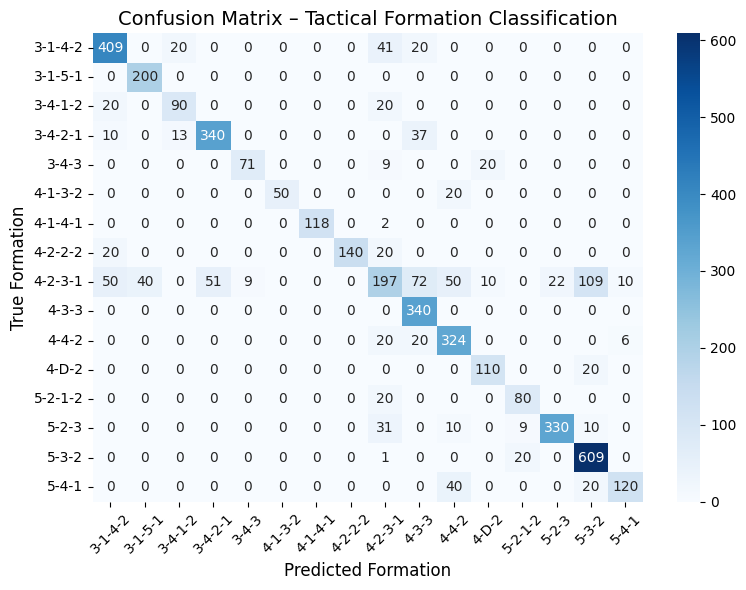

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
# Ensure categorical dtype for consistency
y_test = y_test.astype("category")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=y_test.cat.categories)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=y_test.cat.categories,
            yticklabels=y_test.cat.categories)
plt.title("Confusion Matrix – Tactical Formation Classification", fontsize=14)
plt.xlabel("Predicted Formation", fontsize=12)
plt.ylabel("True Formation", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#  Individual role classification for players defending corners in football (soccer)  Gabriel Anzer, Pascal Bauer*, and Joshua Wyatt Smith 

/tmp/ipykernel_1637279/639350362.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(15), x="importance", y="feature", palette="viridis")


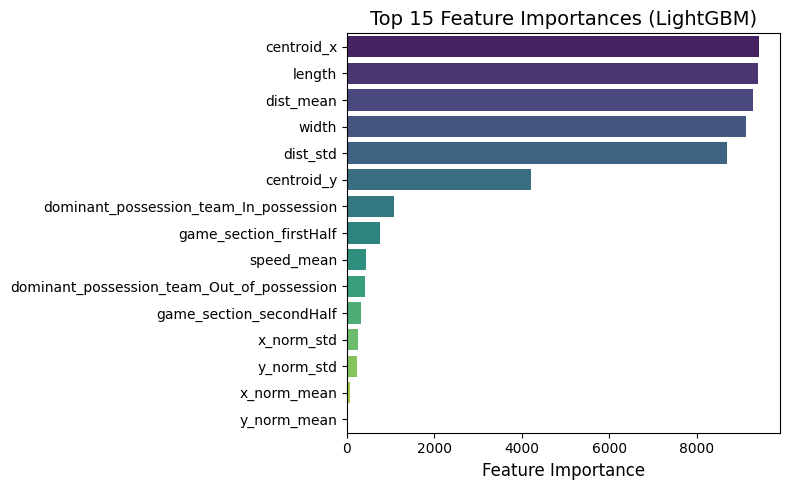

In [16]:
# Feature Importance Plot
try:
    ohe = pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
    cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
    all_feature_names = num_cols + cat_feature_names

    importances = pipe.named_steps["model"].feature_importances_

    if len(importances) == len(all_feature_names):
        feat_imp = pd.DataFrame({
            "feature": all_feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False)

        plt.figure(figsize=(8,5))
        sns.barplot(data=feat_imp.head(15), x="importance", y="feature", palette="viridis")
        plt.title("Top 15 Feature Importances (LightGBM)", fontsize=14)
        plt.xlabel("Feature Importance", fontsize=12)
        plt.ylabel("")
        plt.tight_layout()
        plt.show()
    else:
        print("Feature count mismatch – skipping importance plot.")
except Exception as e:
    print(f"Could not extract feature importances: {e}")
    
    
# Gudmundsson & Horton, 2017 – Spatio-temporal analysis of team formations in football
# Decroos et al., 2019 – Actions Speak Louder Than Goals

#### 10. Save the Trained Pipeline

In [14]:
bundle = {
    "pipe": pipe,
    "num_cols": num_cols,
    "cat_cols": cat_cols
}

joblib.dump(bundle, "lgbm_bundle.joblib")
print("\nSaved pipeline bundle: lgbm_bundle.joblib")


Saved pipeline bundle: lgbm_bundle.joblib
